# Example steps and codes running hypoddpy for earthquake relocation

In [1]:
#import needed packages.
""" 
    Download hypoDD at https://www.ldeo.columbia.edu/~felixw/hypoDD.html
    Or use the copy included in this python interface package.
"""
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from hypoxpy import utils
import hypoxpy.HypoDDCore as hypoddcore
import matplotlib.pyplot as plt

In [ ]:
binpath='/Users/xtyang/bin' #path to hypoDD binaries.
indir='input_GAMMA'
outdir='output_GAMMA'
if not os.path.exists(outdir):
    os.makedirs(outdir)
namebase='GAMMA'
station_file=os.path.join(indir,'GAMMA_station_list.json')
station_file_reformat=os.path.join(indir,'station.dat')
event_file=os.path.join(indir,'GAMMA_catalog.csv')
phase_file=os.path.join(indir,'GAMMA_picks.csv') #input original phase file.
evid_label='event_id' #column name for event ID in the input event and pick files.
mapping_evid=True #whether to remap event IDs to integers starting from 1 for HypoDD compatibility.
        #If False, original event IDs are used (may cause issues if IDs are not integers or not starting from 1).
        #THIS SHOULD BE TRUE, UNLESS YOU ARE SURE YOUR EVENT IDS ARE INTEGERS STARTING FROM 1.
save_cleaned_data=True #whether to save cleaned event and pick data after removing invalid entries.
        #THIS SHOULD BE TRUE IF mapping_evid IS TRUE. IT IS SET AUTOMATICALLY IN THE FUNCTION IF mapping_evid IS TRUE.
cleaned_eventfile = os.path.splitext(event_file)[0] + "_cleaned.csv"
cleaned_pickfile = os.path.splitext(phase_file)[0] + "_cleaned.csv"

phase_file_reformat=f'{indir}/{namebase}_phase_ready.pha' #output reformatted phase file for hypoDD.

# combine network and station for HypoDD format.
combine_net_sta=True
#depth correction for phase file reformatting to avoid air quakes.
dep_corr = 5  #km, modify velocity model accordingly.

#
cleanup=True #whether to clean up intermediate files.


In [3]:
# 1. reformat station and phase files
utils.reformat_stainfo_hypodd(station_file, station_file_reformat,informat='json-gamma',combine_net_sta=combine_net_sta) # type: ignore
utils.convert_gamma2hypodd(event_file,phase_file,outfile=phase_file_reformat,
                     combine_net_sta=combine_net_sta,qc=False,verbose=False,
                     evid_label=evid_label,mapping_evid=mapping_evid,save_cleaned_data=save_cleaned_data,
                     cleaned_eventfile=cleaned_eventfile,cleaned_pickfile=cleaned_pickfile) # pyright: ignore[reportUndefinedVariable]


Cleaned event data saved to input_GAMMA/GAMMA_catalog_cleaned.csv
Cleaned pick data saved to input_GAMMA/GAMMA_picks_cleaned.csv


Converting GAMMA to HypoDD phase file: 100%|██████████| 9257/9257 [00:02<00:00, 3767.46it/s]


In [4]:
print("[TIMER] HypoDD started")

# -------------------------------
# 2. Configure hypoDD running settings
# -------------------------------
hypoddconfig = hypoddcore.HypoDDConfig(binpath=binpath,indir=indir,outdir=outdir,namebase=namebase,
    station_file=station_file_reformat,phase_file=phase_file_reformat)

# -------------------------------
# 3. hypoDD (core relocation)
# -------------------------------
t0 = utils.tic()
print(f"Running hypoDD ")
out_catalog = hypoddconfig.run(cleanup=cleanup)
utils.toc(t0, f"Run hypoDD")


[TIMER] HypoDD started
Running hypoDD 
running ph2dt...
[INFO] ph2dt completed: output_GAMMA/GAMMA.ph2dt
[INFO] Wrote output catalog: output_GAMMA/GAMMA.ctlg with 2012 events.
[INFO] Cleaned up intermediate files.
[TIMER] Run hypoDD: 4.94 s


In [9]:
quakes_original=pd.read_csv(cleaned_eventfile)
print(quakes_original)
quakes=pd.read_csv(out_catalog,header=None,names=["datetime","latitude","longitude","depth","magnitude","evid"])
print(quakes)

                         time  magnitude  longitude  latitude   depth(m)  \
0     2021-01-01T04:52:27.049      1.501   -161.060    54.902   2008.768   
1     2021-01-01T05:28:14.484      2.324   -161.003    55.113  57377.157   
2     2021-01-01T05:28:23.897      2.640   -161.003    55.125  61000.000   
3     2021-01-01T08:31:49.150      1.879   -161.090    54.902  53225.937   
4     2021-01-01T08:31:58.250      1.906   -161.197    54.903  57070.733   
...                       ...        ...        ...       ...        ...   
9252  2021-12-31T23:10:55.735      2.990   -162.185    54.905  20903.311   
9253  2021-12-31T23:15:22.611      1.918   -162.753    55.650  61000.000   
9254  2021-12-31T23:17:31.632      1.033   -161.525    55.342  12596.259   
9255  2021-12-31T23:23:21.146      1.727   -162.152    55.567  61000.000   
9256  2021-12-31T23:28:02.339      0.731   -161.556    55.283  29045.795   

      sigma_time  sigma_amp  cov_time_amp  gamma_score  event_index  \
0          0.093

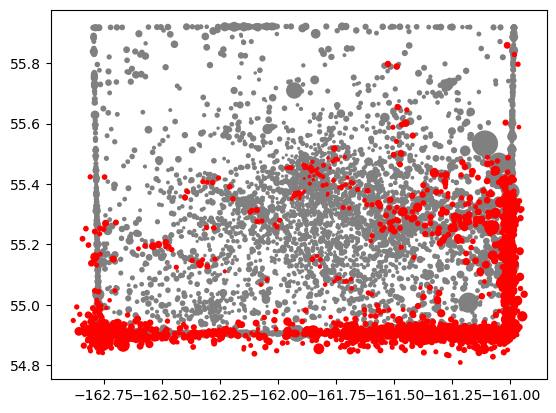

In [18]:
#plot original events with black color
plt.scatter(quakes_original.longitude,quakes_original.latitude,5*np.power(2,quakes_original.magnitude),facecolors='0.5',edgecolors='none')
# plt.scatter(quakes.longitude,quakes.latitude,5*np.power(2,quakes.magnitude),quakes.depth,edgecolors='none')
# plt.colorbar(label='depth (km)')
plt.scatter(quakes.longitude,quakes.latitude,5*np.power(2,quakes.magnitude),'r',edgecolors='none')
plt.show()